## Exercise 4 - Hierarchical Models and Testing
**Group:** Andrea Raachou, Jenny Laberg Nilsson, Preston Stover

**Course:** BERN02   
**Semester:** Autumn 2026 

In [1]:
import pandas as pd
import numpy as np
import bambi as bmb # Bayesian Model-Building Interface in Python
import arviz as az # essential dependency
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pooch import retrieve # Download files over http

### Import Data
Data composed of 7 experimental results of hotel towel reuse with control and social norm conservation messaging. Data compiled by Scheibehenne et al., 2016.

In [2]:
# Read data, put in pandas dataframe
url = "https://osf.io/download/qsb3f"
path = retrieve(url=url, known_hash=None)
data = pd.read_csv(path, encoding="latin1", sep = ';')
#print(data.head())

### Data Wrangling
Data is assigned into 'social' (norm messaging) and 'control' (conserve messaging) variables for each of the studies. Resuse success counted binomially in 'yes' and 'no' categorized variables.

In [3]:
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 different studies
control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set. an give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')
#print(combined_data.head())

### Theory
#### Introduction

### Exercise Summary
This study analyzes data from a collection of randomized controlled trials evaluating the effectiveness of *descriptive social norms* on hotel guests' towel reuse behavior (Scheibehenne et al., 2016). Descriptive social norm messages inform guests about the observed majority behavior of previous occupants (e.g., "75% of guests who stayed in this room reused their towels at least once during their stay."). In addition, a standard control message that doesn't include the behaviour of previous occupants is used (e.g., "You can show your respect for nature by reusing your towels")

The response variable represents aggregated count data (number of towels reused out of total opportunities per condition), which follows a Binomial distribution.

Using Bambi(PyMC-based) functions such as **bmb.Model** and **.prior_predictive**, we implement a Bayesian hierarchical binomial linear regression model that uses a global slope $\beta_1$ and study-specific intercepts $u_j$ to account for deviations between studies $j$. We use Bambi to perform prior predictive checks, refine the priors to eliminate divergence, and test our hypotheses using Bayesian inference.


#### Hypothesis testing
To evaluate the effectiveness of the descriptive social norm intervention relative to standard control messaging, we formulate hypotheses directly targeting the fixed-effect slope parameter ($\beta_1$), which represents the log-odds ratio of towel reuse under the intervention:
* Null Hypothesis ($H_0$): $\beta_1 = 0$: The descriptive social norm message has no effect on the log-odds (probability) of towel reuse.
* Alternative Hypothesis ($H_1$): $\beta_1 \neq 0$: The descriptive social norm message alters the log-odds of towel reuse relative to the standard control message.

#### Hierarchical Model Structure
We employ a Hierarchical Binomial Logistic Model that has a group specific intercept for each study (random effect) and use a shared slope (fixed effect). This means that the effect is overall the same (difference between no social norm and with social norm) but that the studies may differ in other ways - like choice of hotel or area, or time of the study.

#### Model 
$$Y_{ij} \mid n_{ij}, p_{ij} \sim \text{Binomial}(n_{ij}, p_{ij})$$
where $Y_{ij}$ is the count of reused towels out of $n_{ij}$ total trials for condition $i$ in study $j$.

The probability of reuse success, $p_ij$, informs the linear predictor $η_ij$ which is defined using the study-specific intercept and the model's regression values: $$\eta_{ij} = \beta_0 + u_j + \beta_1 x_{ij}$$

where $u_{j}$ represents the random effect for each study, $\beta_0 + u_{j}$ represents the baseline intercept for each study and $\beta_1$ represents the fixed-effected slope. The natural log odds ratio is defined:

$$\text{logit}(p_{ij}) = \ln\left(\frac{p_{ij}}{1 - p_{ij}}\right) = \eta_{ij} \iff p_{ij} = \frac{1}{1 + \exp(-\eta_{ij})}$$



#### Prior Specifications
The priors used in this model are 
 - $\beta_0$: prior for the baseline log-odds
 - $\beta_1$: prior for the social-norm effect
 - $u_j$: study-specific deviation from the overall intercept
 - $\tau$: between-study standard deviation.

We initially use Bambi's default prior distributions to the fixed and random effects, and later manually change the priors for the intercept ($\beta_0$) and random-effect SD ($\tau$). They are specified using the following distributions, with hyperparameters $\mu_{\beta_0}$, $\sigma_{\beta_0}$, $\mu_{\beta_1}$, $\sigma_{\beta_1}$, and $\sigma_\tau$:

$$
\begin{aligned}
\beta_0 &\sim N(\mu_{\beta_0}, \sigma_{\beta_0}) \\
\beta_1 &\sim N(\mu_{\beta_1}, \sigma_{\beta_1}) \\
u_j &\sim N(0, \tau)\\
\tau &\sim HalfNormal(\sigma_\tau) 
\end{aligned}
$$

The prior distributions for the final model are
$$
\begin{aligned}
\beta_0 &\sim N(0, 1) \\
\beta_1 &\sim N(0, 1) \\
u_j &\sim N(0, \tau)\\
\tau &\sim HalfNormal(1.5) 
\end{aligned}
$$


### Model Setup

In [4]:
# Model with random interecept for each study and group (control/social) as intercept
m1 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial") 
print(m1)

       Formula: p(reuse, total) ~ 1 + group + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))


### Fit the model

In [5]:
idata1 = m1.fit() 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 22 divergences after tuning. Increase `target_accept` or reparameterize.


After this initial model fit using Bambis' automatically specified prior distributions, the output gives some warnings that means that the MCMC sampler had some difficulty exploring the posterior distribution (many divergences and rhat statistic larger than 1.01 for some parameters).

### Evaluate priors and improve model fit

In [6]:
# There is a large numer of divergences (28) - which indicates a problem with the underlying model (according to bambi website)

# Look at the prior predictive distribution, see plots below
idata_prior = m1.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]

Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


This function creates a plot of the prior predictive distribution. The red line represents the actual observed proportion of reused / total towels. An intuitive way of interpreting the plot: if the priors used in the model were true, what observations would the model consider plausible? This is represented byy the grey bars.

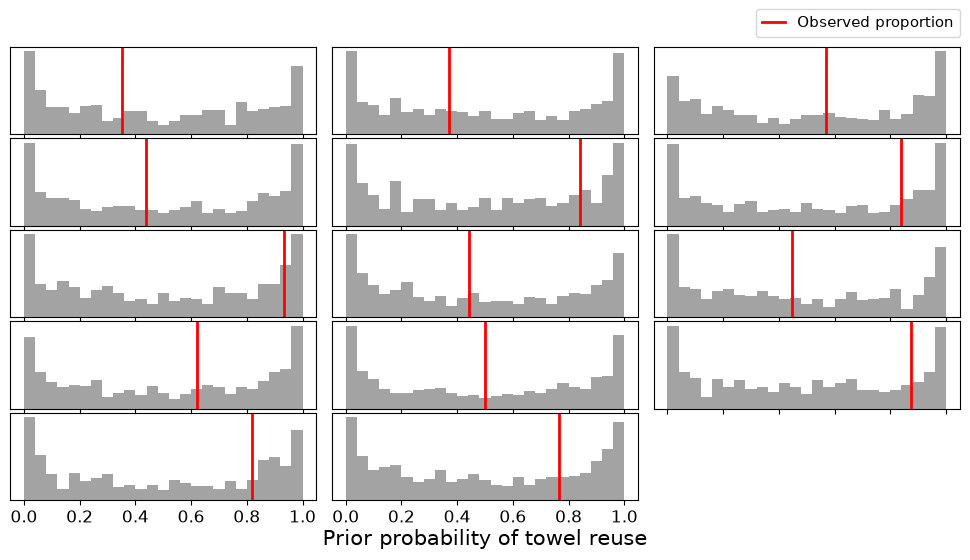

In [7]:
def plot_prior_predictive(df, prior):
    total = df["total"].values
    reuse = df["reuse"].values
    fig, axes = plt.subplots(5, 3, figsize=(10, 6), sharex="col")

    for idx, ax in enumerate(axes.ravel()):
        # Stop after the 14 observations
        if idx >= len(df):
            ax.axis("off")
            continue

        pps = prior.sel({"__obs__": idx})
        observed_proportion = reuse[idx] / total[idx]
        ax.hist(pps, bins=25, color="#a3a3a3")
        ax.axvline(observed_proportion, color="red", lw=2)
        ax.set_yticks([])
        ax.tick_params(labelsize=12)

    fig.subplots_adjust(
        left=0.025,
        right=0.975,
        hspace=0.05,
        wspace=0.05,
        bottom=0.125)

    fig.legend(
        handles=[
            Line2D(
                [0], [0],
                label="Observed proportion",
                color="red",
                linewidth=2)],
        handlelength=1.5,
        handletextpad=0.8,
        borderaxespad=0,
        frameon=True,
        fontsize=11,
        bbox_to_anchor=(0.975, 0.92),
        loc="right")

    fig.text(
        0.5,
        0.05,
        "Prior probability of towel reuse",
        fontsize=15,
        ha="center",
        va="baseline")

# Plot the priors 
plot_prior_predictive(combined_data, prior)



This plots show that the initial prior prediction distributions are too wide. To address this, we refine the prior specifications by reducing the ($\sigma$) parameter to constrain the model.

In [8]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1), # Changed from 1.5 to 1
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2)) # Changed from 1 to 2
}
m2 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial", priors=priors)
m2

idata2 = m2.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.


Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


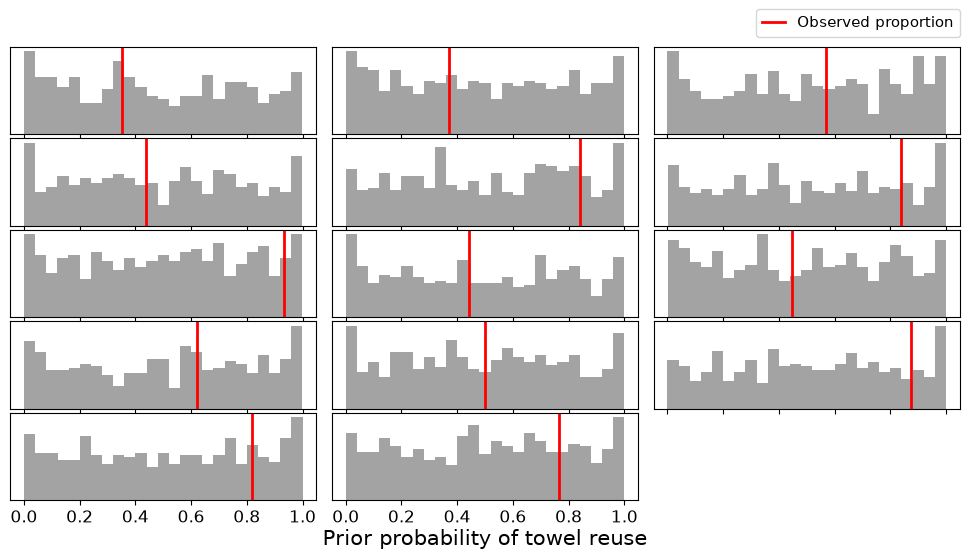

In [9]:
# Validating priors
m2.build()
idata_prior = m2.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
plot_prior_predictive(combined_data, prior)

Slightly better but still not good enough.

Initializing NUTS using jitter+adapt_diag...


       Formula: p(reuse, total) ~ 1 + group + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.0)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.5))


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 85 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


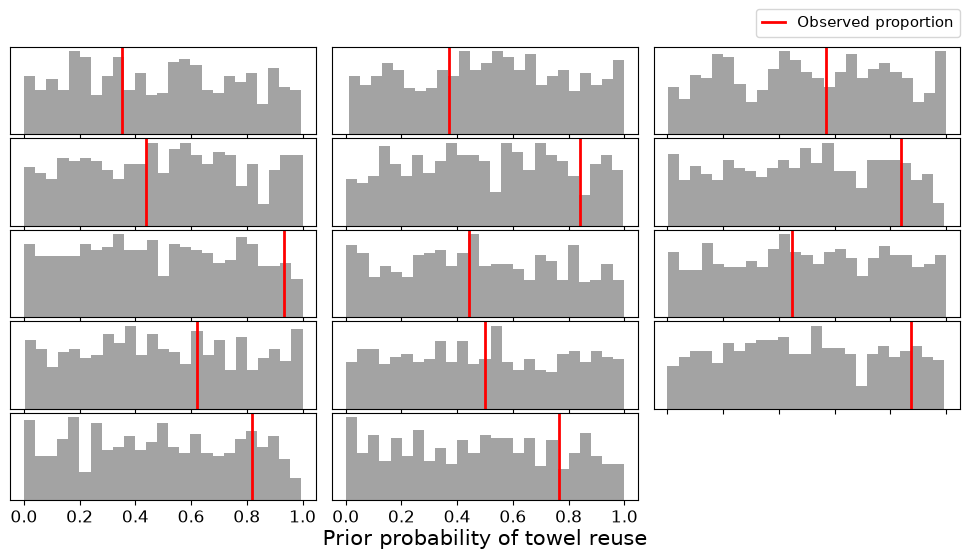

In [15]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1), # Same as in m2
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1.5)) # Changed sigma from 2 to 1.5.
}
m3 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial", priors=priors)
print(m3)

idata3 = m3.fit()

m3.build()
idata_prior = m3.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
plot_prior_predictive(combined_data, prior)

Lowering the hyper-prior scale gives us a better prior predictive distribution. On the probability scale, the simulated outcomes spread evenly between 0 and 1. This keeps the priors weakly informative while avoiding extreme values near 0% or 100%. Importantly, all observed study proportions (red lines) fall well within these predictions.

### Final model

In [11]:
idata3 = m3.fit(target_accept = 0.95) # update the model target acceptance from 1 to 0.95

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Here, we generate MCMC trace plots (az.plot_trace) to visually assess chain convergence and mixing across our model parameters ($\beta_0$, $\beta_1$, $u_j$, and $\tau$).

Data variables:
    Intercept      (chain, draw) float64 32kB 0.01518 0.5201 ... 0.1568 0.1447
    group          (chain, draw, group_dim) float64 32kB 0.2407 0.2893 ... 0.273
    1|study_sigma  (chain, draw) float64 32kB 1.25 1.49 1.009 ... 1.467 1.261
    1|study        (chain, draw, study__factor_dim) float64 224kB -0.7381 ......


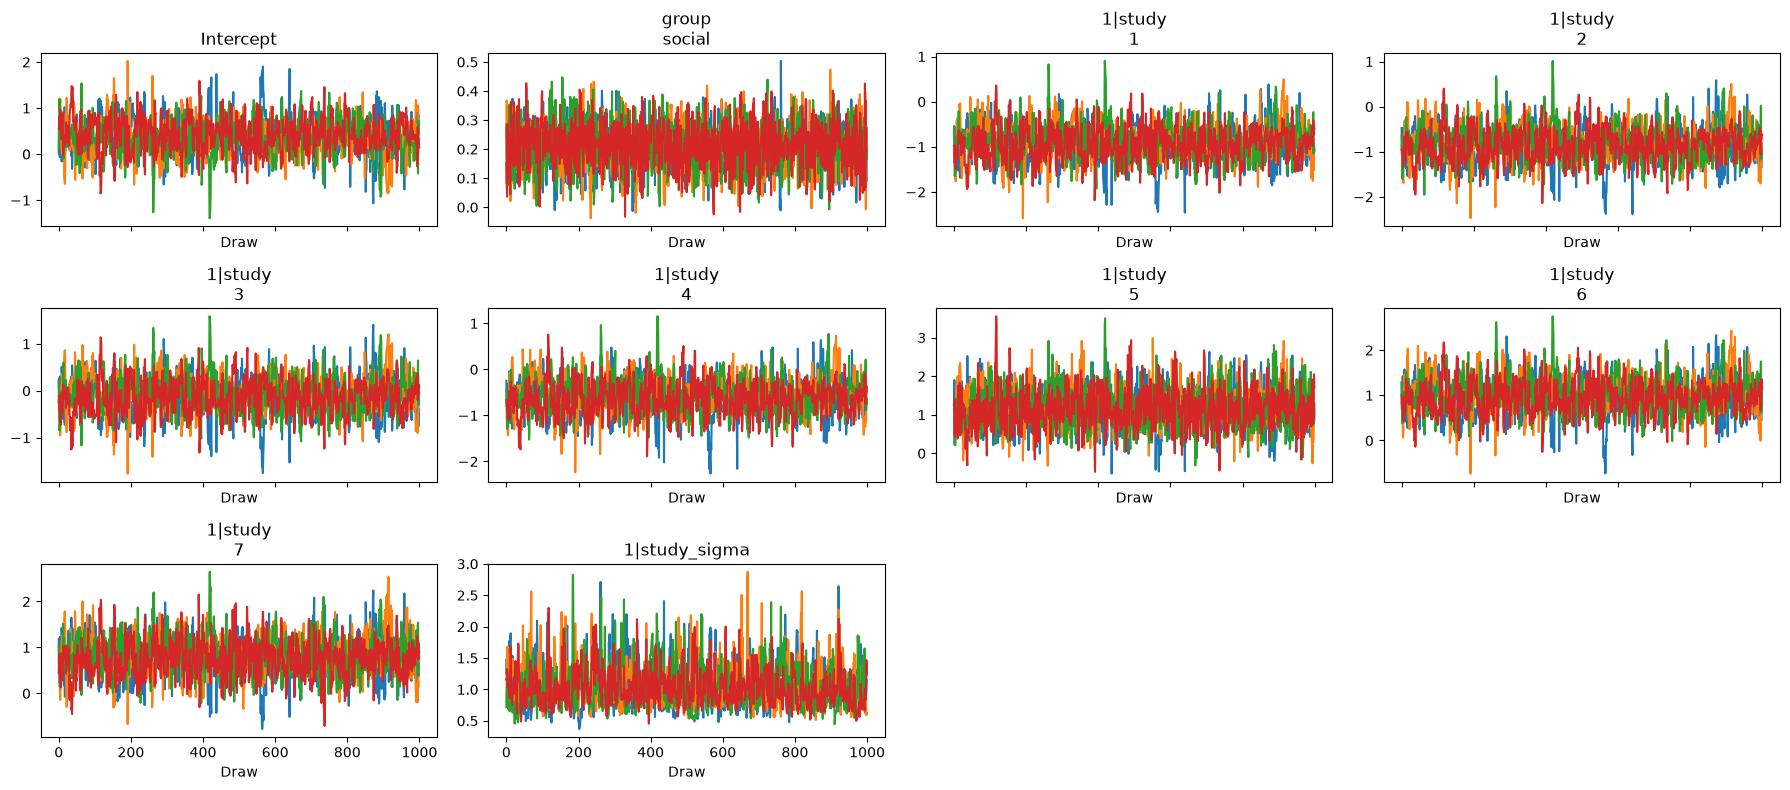

In [12]:
var_names = ["Intercept", "group", "1|study", "1|study_sigma"]
az.plot_trace(idata3, var_names=var_names)
plt.gcf().set_size_inches(18, 8)
plt.tight_layout()

"""
# Find all axes and make their y-axis limits the same
all_axes = plt.gcf().axes

y_limits = [ax.get_ylim() for ax in all_axes]
y_min = min(y[0] for y in y_limits)
y_max = max(y[1] for y in y_limits)

for ax in all_axes:
    ax.set_ylim(y_min, y_max)

"""
print(idata3.posterior.data_vars)


Visual inspection of the MCMC trace plots confirms strong sampling performance and convergence across all four chains. The independent Markov chains overlap significantly with no noticible trends or drift for all ten plots.

### Compare predictors
We now make a summary of the posterior distributions for the primary model parameters using the posterior mean and 90% probabilty intervals.

In [13]:
summary = az.summary(idata3, ci_prob=0.90, kind="stats")
print(summary)
combined_data

                mean     sd eti90_lb eti90_ub
Intercept       0.38   0.38    -0.25     0.99
group[social]   0.21  0.078    0.078     0.34
1|study_sigma      1   0.33     0.64      1.7
1|study[1]      -0.9   0.39     -1.5    -0.26
1|study[2]     -0.83   0.38     -1.4    -0.21
1|study[3]      -0.1   0.39    -0.72     0.52
1|study[4]      -0.6   0.38     -1.2    0.025
1|study[5]       1.2   0.51     0.39        2
1|study[6]      0.98   0.39     0.37      1.6
1|study[7]      0.79   0.41     0.12      1.5


,reuse,total,group,study
0,74,211,control,1
1,103,277,control,2
2,77,135,control,3
3,82,187,control,4
4,21,25,control,5
5,123,147,control,6
6,28,30,control,7
7,98,222,social,1
8,587,1318,social,2
9,406,655,social,3


### Discussion

The logistic regression parameters output from az.summary() are on the log-odds scale. We can calculate the odds ratio values if we exponentiate $\beta_1$: 
  $$\text{OR} = \exp(\beta_1) = \exp(0.21) \approx 1.234$$

This is a useful transformation because it allows a meaningful quanitification of the results. Based on our measured $\beta_1$, the model suggests that guests have 1.234 higher odds to reuse their towels when social norm messaging is used: a 23.4% increase in the odds of towel reuse. 

We can determine the 90% Credible Interval for the odds ratio by exponentiating the interval bounds:
  $$[\exp(0.084), \, \exp(0.34)] \approx [1.088, \, 1.405]$$


Hypotheses restated:
* $H_0$:  $\beta_1 = 0$: Descriptive social norm messaging has no signficant effect on towel reuse.
* $H_1$:  $\beta_1 \neq 0$: Descriptive social norm messaging has a signficant effect on towel reuse.

Expressed as an odds ratio, exposure to descriptive social norms increases the odds of hotel guest towel reuse by approximately $23\%$ ($e^{0.21} \approx 1.23$). Because the entire 90% Equal-Tailed Interval ($[0.084, 0.34]$) sits strictly above zero, $100\%$ of the posterior samples indicate a positive effect. We reject the null hypothesis $H_0$ at the 90% credibility level. 
 

### References
- Capretto, T., Camilleri, A. R., & Bambi Contributors. (n.d.). Hierarchical Binomial Logistic Regression in Bambi. Bambi Documentation. Retrieved from https://bambinos.github.io/bambi/notebooks/hierarchical_binomial_bambi.html
- Scheibehenne, B., Jamil, T., & Wagenmakers, E. J. (2016). Bayesian evidence synthesis can reconcile seemingly conflicting results: The case of hotel towel reuse. *Journal of Environmental Psychology*, 48, 28–35. https://doi.org/10.1016/j.jenvp.2016.08.003